In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
import joblib

In [2]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df["TotalCharges"]= df["TotalCharges"].replace({" " : 0.0}).astype(float)

In [4]:
df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
x = df["Churn"].value_counts()
ratio = x.iloc[0]/x.iloc[1]

print(f"Imbalance ratio : {ratio:.3f} : 1")

Imbalance ratio : 2.768 : 1


doesn't effect the model that much

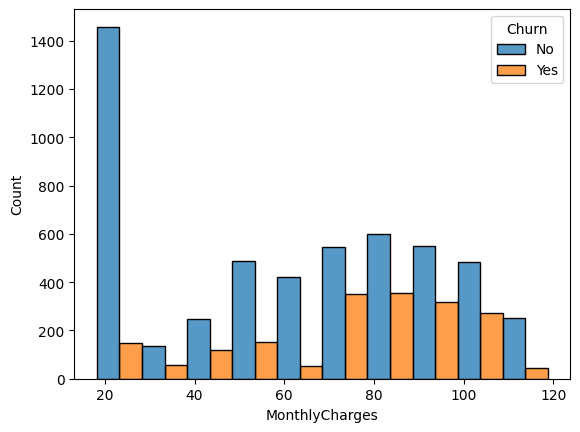

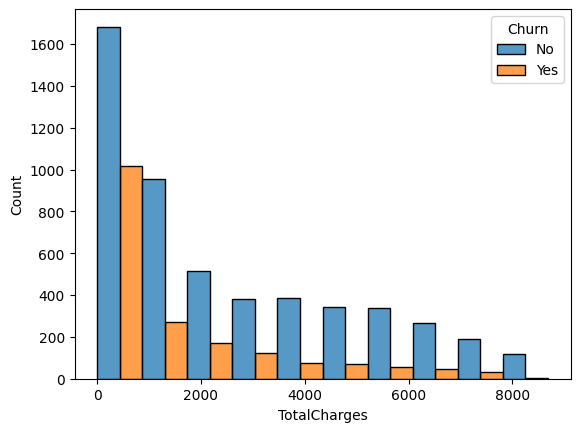

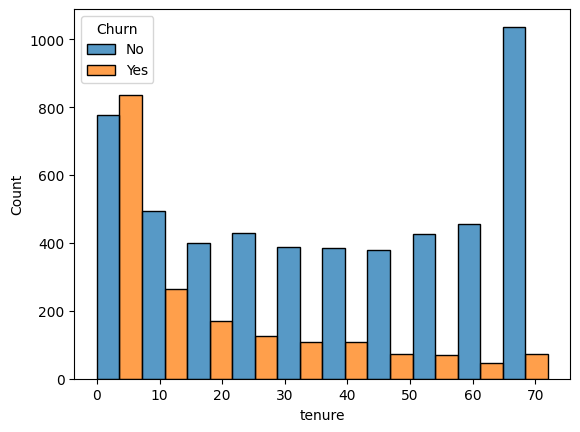

In [6]:
sns.histplot(
    x="MonthlyCharges",
    data=df,
    bins=10,
    hue="Churn",
    multiple="dodge"
)
plt.show()

sns.histplot(
    x="TotalCharges",
    data=df,
    bins=10,
    hue="Churn",
    multiple="dodge"
)
plt.show()

sns.histplot(
    x="tenure",
    data=df,
    bins=10,
    hue="Churn",
    multiple="dodge"
)
plt.show()

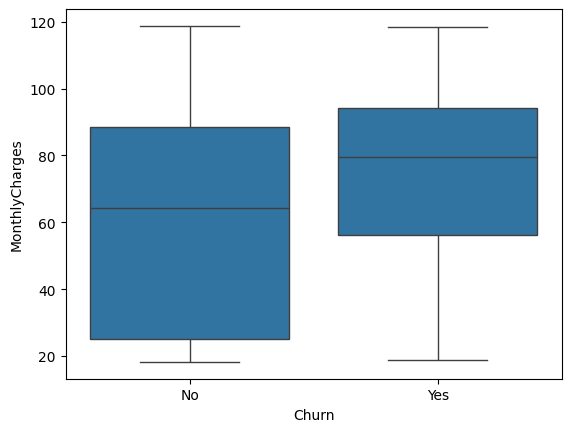

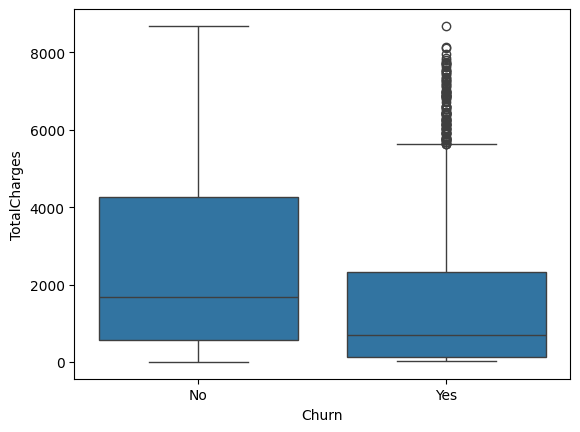

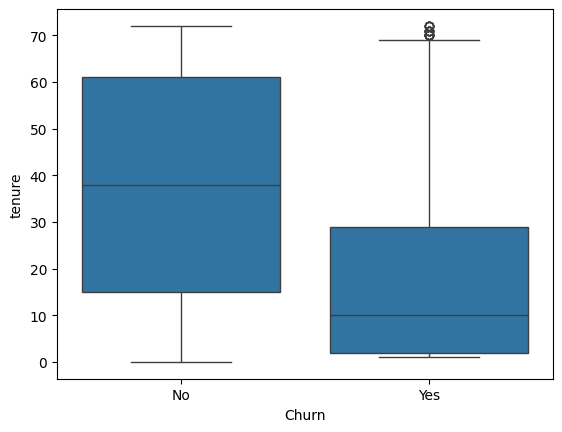

In [7]:
sns.boxplot(x = "Churn", y = "MonthlyCharges", data = df)
plt.show()
sns.boxplot(x = "Churn", y = "TotalCharges", data = df)
plt.show()
sns.boxplot(x = "Churn", y = "tenure", data = df)
plt.show()

<Axes: xlabel='Contract', ylabel='count'>

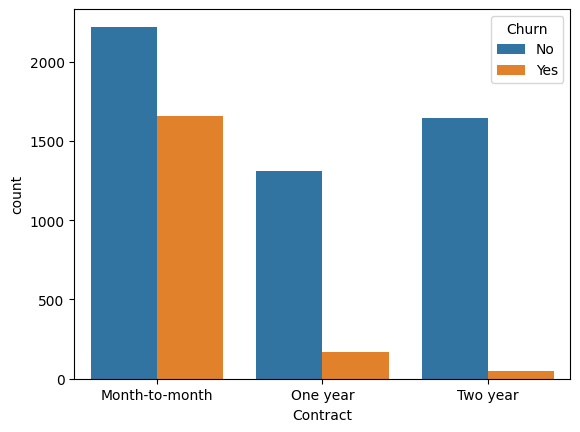

In [8]:
sns.countplot(x = "Contract", data = df,hue = "Churn")

In [9]:
columns = df.columns
for col in columns :
    print(col,df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (a

In [10]:
Binary_col = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]
for col in Binary_col :
    df[col] =df[col].map(
        {"Yes" :1,"No" : 0}
    )

df["gender"] =df["gender"].map(
    {"Male" :1,"Female" : 0}
)

df = pd.get_dummies(
    df,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True
)

In [11]:
X = df.drop(columns=["customerID","Churn"])
y = df["Churn"]
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [12]:
X_train, X_test, train_y, test_y = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    )

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
print(X.isnull().sum())

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

In [15]:
X_train.shape[0]


5634

In [16]:
X_test.shape[0]

1409

In [17]:
model = LogisticRegression()

model.fit(X_train, train_y)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(test_y, predictions))

print(confusion_matrix(test_y, predictions))

print(classification_report(test_y, predictions))

Accuracy: 0.8204400283889283
[[934 102]
 [151 222]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
8,TotalCharges,0.649427
11,InternetService_Fiber optic,0.619853
24,StreamingMovies_Yes,0.228714
22,StreamingTV_Yes,0.179380
10,MultipleLines_Yes,0.168199
6,PaperlessBilling,0.163829
28,PaymentMethod_Electronic check,0.150618
1,SeniorCitizen,0.058854
9,MultipleLines_No phone service,0.035633
18,DeviceProtection_Yes,0.027786


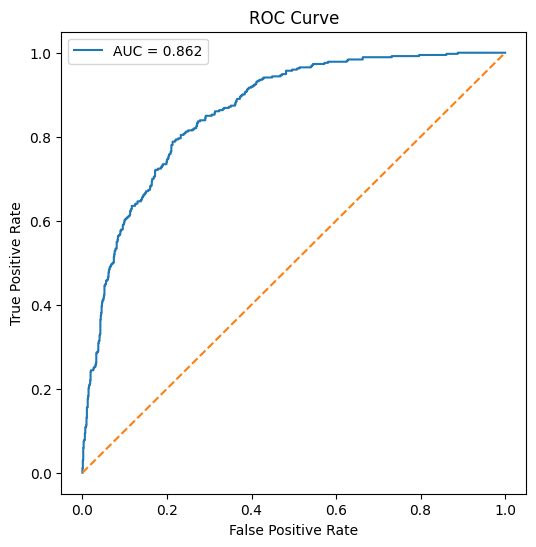

ROC-AUC: 0.8621256741229931


In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(test_y, y_prob)

auc = roc_auc_score(test_y, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", auc)

In [20]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_raw, y_train)
dt_predictions = dt_model.predict(X_test_raw)

In [22]:
print("Accuracy:", accuracy_score(y_test, dt_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Accuracy: 0.7125621007806955

Confusion Matrix:
[[837 199]
 [206 167]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1036
           1       0.46      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



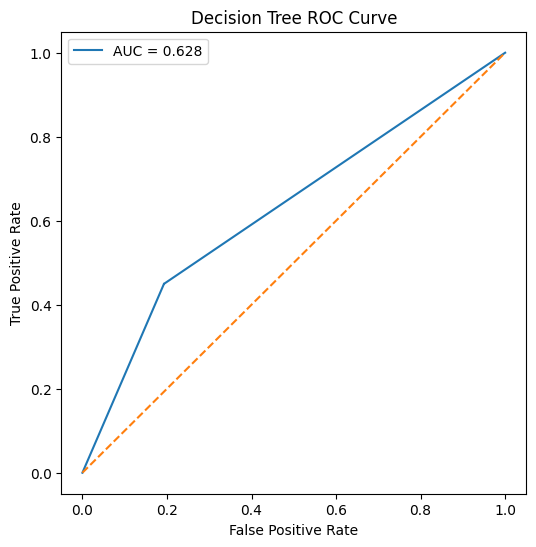

ROC-AUC: 0.6283693210636911


In [23]:
dt_prob = dt_model.predict_proba(X_test_raw)[:, 1]

fpr, tpr, _ = roc_curve(y_test, dt_prob)

auc = roc_auc_score(y_test, dt_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", auc)

In [24]:
print("Training Accuracy:", dt_model.score(X_train_raw, y_train))
print("Testing Accuracy:", dt_model.score(X_test_raw, y_test))

Training Accuracy: 0.9985800496982605
Testing Accuracy: 0.7125621007806955


In [25]:
depths = range(1, 21)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_raw, y_train)

    train_scores.append(model.score(X_train_raw, y_train))
    test_scores.append(model.score(X_test_raw, y_test))

for d, train_acc, test_acc in zip(depths, train_scores, test_scores):
    print(
        f"Depth: {d:2d} | "
        f"Train: {train_acc:.3f} | "
        f"Test: {test_acc:.3f}"
    )

Depth:  1 | Train: 0.734 | Test: 0.735
Depth:  2 | Train: 0.787 | Test: 0.802
Depth:  3 | Train: 0.787 | Test: 0.802
Depth:  4 | Train: 0.790 | Test: 0.803
Depth:  5 | Train: 0.797 | Test: 0.806
Depth:  6 | Train: 0.802 | Test: 0.798
Depth:  7 | Train: 0.818 | Test: 0.789
Depth:  8 | Train: 0.833 | Test: 0.787
Depth:  9 | Train: 0.855 | Test: 0.774
Depth: 10 | Train: 0.874 | Test: 0.764
Depth: 11 | Train: 0.896 | Test: 0.751
Depth: 12 | Train: 0.917 | Test: 0.736
Depth: 13 | Train: 0.938 | Test: 0.736
Depth: 14 | Train: 0.952 | Test: 0.729
Depth: 15 | Train: 0.965 | Test: 0.715
Depth: 16 | Train: 0.977 | Test: 0.703
Depth: 17 | Train: 0.985 | Test: 0.713
Depth: 18 | Train: 0.989 | Test: 0.715
Depth: 19 | Train: 0.993 | Test: 0.716
Depth: 20 | Train: 0.994 | Test: 0.705


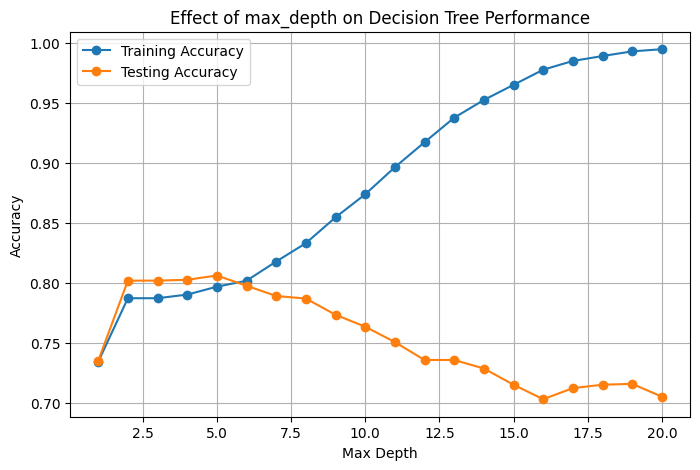

In [26]:
plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, marker='o', label="Training Accuracy")
plt.plot(depths, test_scores, marker='o', label="Testing Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on Decision Tree Performance")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_raw, y_train)

dt_predictions = dt_model.predict(X_test_raw)

Accuracy: 0.8062455642299503

Confusion Matrix:
[[964  72]
 [201 172]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409


ROC-AUC: 0.8481722338960944


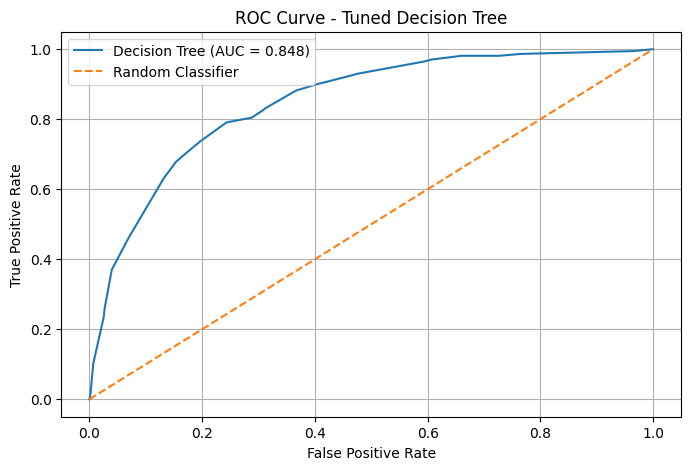

In [28]:

dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Accuracy:", dt_accuracy)

cm = confusion_matrix(y_test, dt_predictions)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

dt_prob = dt_model.predict_proba(X_test_raw)[:, 1]

auc = roc_auc_score(y_test, dt_prob)
print("\nROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, dt_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth = 10,
    random_state=42
)
rf_model.fit(X_train_raw,y_train)
rf_predictions = rf_model.predict(X_test_raw)
rf_accuracy = accuracy_score(y_test,rf_predictions)
rf_cm = confusion_matrix(y_test,rf_predictions)

print(f"""
      Accuracy :
        {rf_accuracy : .3f} 
      Confusion Matrix :
        {rf_cm} 
      Classification_report :
      {classification_report(y_test,rf_predictions)}
      """)



      Accuracy :
         0.813 
      Confusion Matrix :
        [[950  86]
 [178 195]] 
      Classification_report :
                    precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

      


#hyperparmeter tuning for random forest
best depth = 10
best estimations = 200


ROC-AUC: 0.860


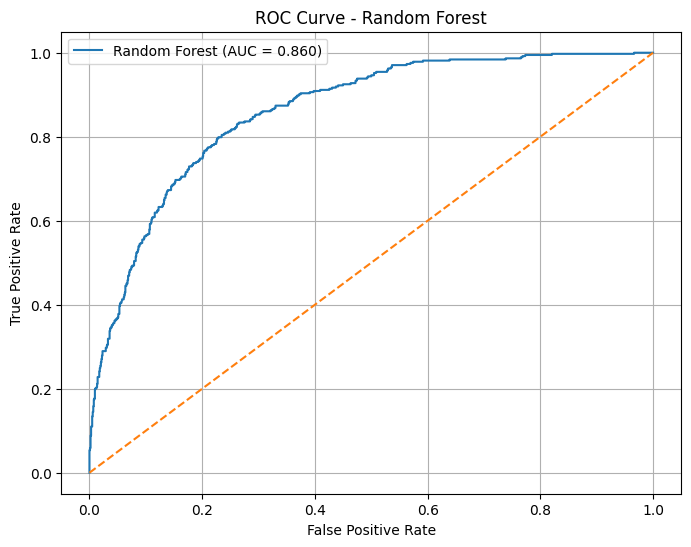

In [30]:
rf_probabilities = rf_model.predict_proba(X_test_raw)

rf_auc = roc_auc_score(y_test, rf_probabilities[:, 1])

print(f"ROC-AUC: {rf_auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probabilities[:, 1]
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
xgb_model =  XGBClassifier(
    n_estimators=10,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_raw, y_train)
xgb_predictions = xgb_model.predict(X_test_raw)

In [32]:
print("Accuracy:", accuracy_score(y_test, xgb_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_predictions))

print("\nClassification Report")
print(classification_report(y_test, xgb_predictions))

xgb_probabilities = xgb_model.predict_proba(X_test_raw)[:,1]

print("\nROC-AUC:",
      roc_auc_score(y_test, xgb_probabilities))

Accuracy: 0.8105039034776437

Confusion Matrix
[[949  87]
 [180 193]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


ROC-AUC: 0.8607424927800265


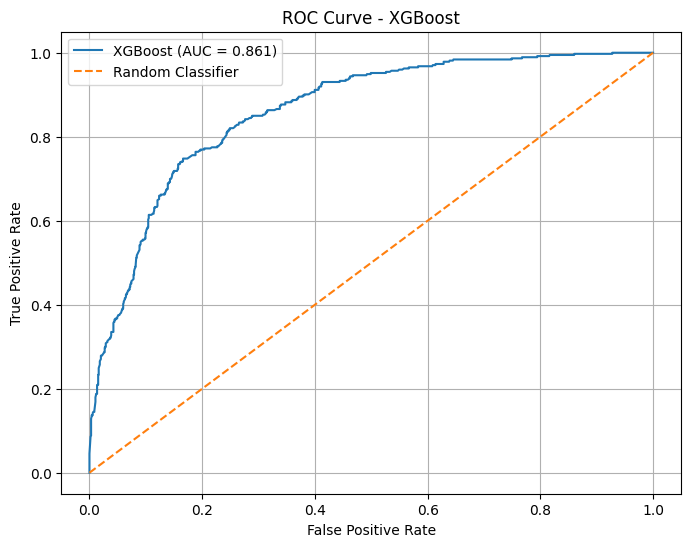

In [33]:
xgb_probabilities = xgb_model.predict_proba(X_test_raw)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_probabilities)

auc = roc_auc_score(y_test, xgb_probabilities)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.show()

#Hyperparametre tuning
n_estimators = 10
max_depth = 4
learning_rate =0.3



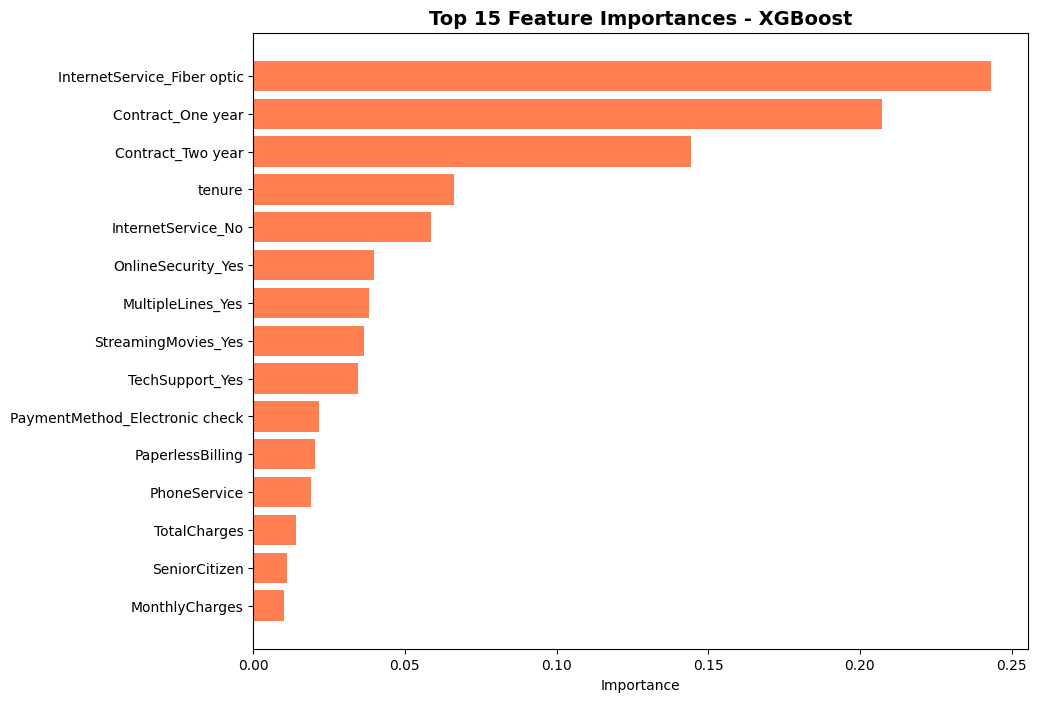

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(10,8))

plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [35]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_raw)

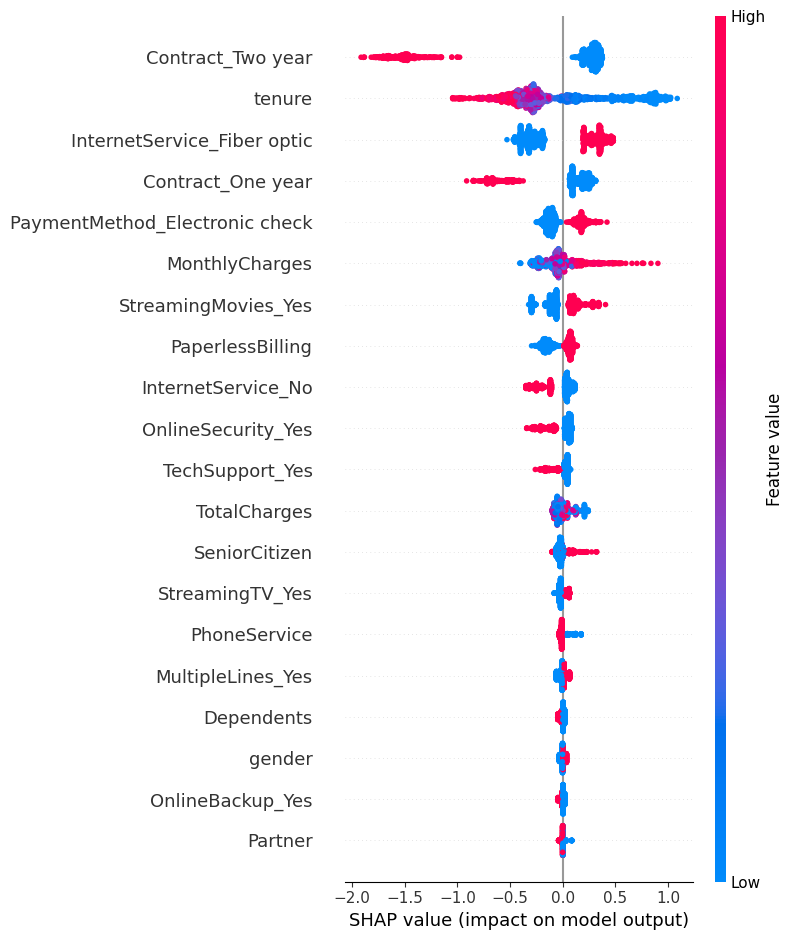

In [38]:
shap.summary_plot(shap_values, X_test_raw)

In [40]:
joblib.dump(xgb_model,"model.pkl")

['model.pkl']

In [44]:
joblib.dump(explainer, "explainer.pkl")

['explainer.pkl']